Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE", as well as your name below:

###### Version 2026.1

In [1]:
NAME = "Samantha A. Salazar"

# Assignment 4: An Exploration of Bayesian Uncertainty

## Introduction
In this assignment, you will explore the nature of Bayeisan uncertainty (and compare it to frequentist expressions of uncertainty) in the context of regression. If you have not reviewed the instructional file that compares frequentist vs. Bayesian uncertainty, please do so before you start this assignment.

### Context
In this assignment you will create several regression models to predict (explain) medical charges using features in the data set. You will use both frequentist and Bayesian approaches, and then examine and discuss the uncertainty associated with key predictors in the data set. 

**Data Overview:**
The data set is a public data set, available several places on the Internet, but sourced from kaggle.com. Below is a description of the variables included in the data set.
* age: age of the beneficiary
* sex: gender of the beneficiary
* bmi: body mass index, providing an understanding of body weights that are relatively high or low relative to height
children: number of children covered by health insurance 
* smoker: smoking status of the beneficiary
* region: the beneficiary's residential area in the US (northeast, southeast, southwest, northwest)
* charges: individual medical costs billed by health insurance

### Imports and Exploration

In [2]:

# import libraries
import numpy as np
import pandas as pd
import statsmodels.api as sm # used to build a frequentist regression model
import pymc as pm # used to build a Bayesian regression model
import arviz as az  # used for Bayesian summaries and diagnostics
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
from tabulate import tabulate
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from mads.lib.path import assets

print("All libraries have successfully imported.")


All libraries have successfully imported.


In [3]:

# read the insurance data from the course assets folder
file = assets.find("insurance.csv")
df = pd.read_csv(file)


In [4]:

# encode categorical variables as numeric values
label_encoder = LabelEncoder()
df['sex'] = label_encoder.fit_transform(df['sex'])
df['smoker'] = label_encoder.fit_transform(df['smoker'])
df['region'] = label_encoder.fit_transform(df['region'])


In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


## 1. Frequentist Linear Regression

Now, we will begin the modeling work with the very familiar, OLS linear regression (the frequentist approach). This approach to regression is by far the most popular, given its simplicity and ubiquity.  

**Task 1.1** (2 points)

In preparation of building a regression model, please start by splitting the data set into features (X) and a target (y). The target (y) will be the variable `charges` and the features will be all the columns except `charges`.

In [6]:

# separate predictors from the outcome variable
X = df.drop(columns = ["charges"])
y = df["charges"]

# preview the feature matrix
X.head()


,age,sex,bmi,children,smoker,region
0,19,0,27.900,0,1,3
1,18,1,33.770,1,0,2
2,28,1,33.000,3,0,2
3,33,1,22.705,0,0,1
4,32,1,28.880,0,0,1


### oral exam explanation

For Task 1.1, I separated the dataset into predictors and outcome. `charges` is the target variable because the goal is to explain or predict medical charges. Every other column remains in `X` as a potential feature for modeling.

**Task 1.2** (1 point)

The standard form for a linear regression model, $Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_p X_p + \epsilon$, includes $\beta_0$, the y-intercept. Recall that statsmodel does not include an intercept in the regression model by default. To include Add a constant to the features (X) dataframe. Task 1.2 is to add an constant to the features (X) data frame that can be used to model the intercept. View the results of your effort by using ```X.head()```.

In [7]:

# add the intercept term required by statsmodels OLS
X = sm.add_constant(X, has_constant = "add")

# confirm that the constant column was added
X.head()


,const,age,sex,bmi,children,smoker,region
0,1.0,19,0,27.900,0,1,3
1,1.0,18,1,33.770,1,0,2
2,1.0,28,1,33.000,3,0,2
3,1.0,33,1,22.705,0,0,1
4,1.0,32,1,28.880,0,0,1


### oral exam explanation

For Task 1.2, I added a constant column so the regression model includes an intercept. In `statsmodels`, the intercept is not automatically included, so `sm.add_constant()` is needed before fitting OLS.


### Oral exam explanation

In this step, I prepared the predictors for the OLS regression model. I selected `age`, `bmi`, and the binary `smoker` variable as the explanatory variables, and `charges` as the response variable.

I also added a constant term to the predictor matrix. The constant represents the intercept of the regression model. In this model, the intercept is the predicted insurance charge when age is 0, BMI is 0, and smoker status is 0. That exact scenario is not realistic, but the intercept is still mathematically necessary because it allows the regression line or regression surface to shift up and down to better fit the data.

The purpose of this step is to create a clean design matrix that can be passed into the OLS model. Once this is done, the model can estimate the separate association between each predictor and insurance charges while holding the other predictors constant.

**Task 1.3** (4 points)

Using your features (X) and target (y), create a OLS model using statsmodel in which the features [`age`,`bmi`,`smoker`,`const`] are used to predict the our y target [`charges`]. Print the summary of the model using $\texttt{.summary()}$.

In [8]:

# select the predictors requested for the regression model
ols_features = ["const", "age", "bmi", "smoker"]

# fit the frequentist OLS model for charges
ols_model = sm.OLS(y, X[ols_features]).fit()

# display coefficient estimates and model diagnostics
ols_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.747
Model:                            OLS   Adj. R-squared:                  0.747
Method:                 Least Squares   F-statistic:                     1316.
Date:                Tue, 02 Jun 2026   Prob (F-statistic):               0.00
Time:                        00:33:47   Log-Likelihood:                -13557.
No. Observations:                1338   AIC:                         2.712e+04
Df Residuals:                    1334   BIC:                         2.714e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.168e+04    937.569    -12.454      0.000   -1.35e+04   -9837.561
age          259.5475     11.934     21.748      0.000     236.136     282.959
bmi          322.6151     27.487     11.737      0.000     268.692     376.538
smoker      2.382e+04    412.867     57.703      0.000     2.3e+04    2.46e+04
==============================================================================
Omnibus:                      299.709   Durbin-Watson:                   2.077
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              710.137
Skew:                           1.213   Prob(JB):                    6.25e-155
Kurtosis:                       5.618   Cond. No.                         289.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### oral exam explanation

For Task 1.3, I fit an OLS regression using `const`, `age`, `bmi`, and `smoker` to predict insurance charges. This gives a frequentist baseline model with point estimates, confidence intervals, and diagnostics that can later be compared with the Bayesian model.


### Oral exam explanation

In this step, I fit a frequentist OLS regression model predicting insurance charges from age, BMI, and smoker status. OLS estimates the coefficients by choosing the values that minimize the sum of squared residuals, where residuals are the differences between observed charges and predicted charges.

Each coefficient has a conditional interpretation. The age coefficient estimates how much insurance charges are expected to change for each additional year of age, holding BMI and smoker status constant. The BMI coefficient estimates the expected change in charges for a one-unit increase in BMI, holding age and smoking constant. The smoker coefficient estimates the expected difference in charges between smokers and non-smokers, holding age and BMI constant.

This model provides a baseline frequentist analysis. Later, I compare these OLS estimates and confidence intervals with Bayesian posterior estimates and credible intervals to see whether the two approaches lead to similar substantive conclusions.

**Task 1.4** (3 points)

Calculate a 95% confidence interval around the coefficient for age.

In [9]:

# extract the point estimate and 95% confidence interval for age
age_coef = ols_model.params.loc["age"]
age_ci = ols_model.conf_int(alpha = 0.05).loc["age"]

# place the result in a readable table
age_ci_df = pd.DataFrame({
    "coefficient": ["age"],
    "point_estimate": [age_coef],
    "lower_95_ci": [age_ci[0]],
    "upper_95_ci": [age_ci[1]]
})

age_ci_df


,coefficient,point_estimate,lower_95_ci,upper_95_ci
0,age,259.547492,236.135695,282.959288


### oral exam explanation

For Task 1.4, I extracted the OLS coefficient for `age` and its 95% confidence interval. This interval gives the range of plausible values for the age effect under the repeated-sampling interpretation of frequentist inference.


### Oral exam explanation

In this step, I extracted the OLS coefficient estimate and 95% confidence interval for age. The age coefficient is approximately 259.55, meaning that each additional year of age is associated with about a $260 increase in predicted insurance charges, holding BMI and smoking status constant.

The 95% confidence interval is approximately 236.14 to 282.96. Because this interval is entirely above zero, the model suggests that age has a statistically meaningful positive association with insurance charges.

It is important to interpret this as an association rather than a guaranteed causal effect. The model controls for BMI and smoker status, but it does not necessarily account for every possible confounding factor. In frequentist terms, the confidence interval means that if we repeatedly sampled data and constructed intervals using this same procedure, about 95% of those intervals would contain the true population coefficient.

**Task 1.5** (3 points)

Using your result from **Task 1.4** provide an interpretation of the coefficient and the uncertainty around it. Be sure to situate your interpretation in the context of the problem.

---

### STUDENT ANSWER

The coefficient for age is positive, with a point estimate of about 259.55. This means that, holding BMI and smoking status constant, each additional year of age is associated with an estimated $259.55 increase in insurance charges.

The 95% confidence interval ranges from about 236.14 to 282.96. Since this interval does not include 0, the model suggests that age is a statistically meaningful positive predictor of insurance charges.

### oral exam explanation

For Task 1.5, I interpreted the age coefficient in context. Holding BMI and smoking status constant, each additional year of age is associated with higher predicted insurance charges, and the confidence interval being entirely above zero supports a positive association.


## 2. Bayesian Linear Regression

In this second section, you will build a basic Bayesian linear regression model using the same target (response) variables, ```X``` and ```y```.

**Task 2.1** (6 points)

Using  ```X``` and ```y``` from Part I, creating a Bayesian linear regression model. Use uninformed priors (assuming that we lack domain knowledge).

In [10]:

# reuse the same predictors from the OLS model
X_bayes = X[ols_features].copy()
y_bayes = y.values

# define the uninformed Bayesian regression model
with pm.Model() as bayes_model:
    # set weak priors for the regression coefficients
    const = pm.Normal("const", mu = 0, sigma = 10000)
    age = pm.Normal("age", mu = 0, sigma = 10000)
    bmi = pm.Normal("bmi", mu = 0, sigma = 10000)
    smoker = pm.Normal("smoker", mu = 0, sigma = 10000)

    # set a positive prior for residual uncertainty
    sigma = pm.HalfNormal("sigma", sigma = 10000)

    # compute the expected charges for each observation
    mu = (
        const
        + age * X_bayes["age"].values
        + bmi * X_bayes["bmi"].values
        + smoker * X_bayes["smoker"].values
    )

    # connect the model prediction to the observed charges
    charges_obs = pm.Normal("charges_obs", mu = mu, sigma = sigma, observed = y_bayes)

    # sample from the posterior distribution
    trace = pm.sample(
        draws = 2000,
        tune = 1000,
        chains = 4,
        target_accept = 0.90,
        random_seed = 42,
        return_inferencedata = True
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [const, age, bmi, smoker, sigma]


Output()

/usr/local/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 15 seconds.


### oral exam explanation

For Task 2.1, I built a Bayesian regression model with weak priors because the prompt assumes limited prior domain knowledge. The model estimates posterior distributions for the intercept, age, BMI, smoker status, and residual uncertainty instead of producing only single coefficient estimates.


### Oral exam explanation

In this step, I fit a Bayesian linear regression model using weak or uninformed priors. The model predicts insurance charges using age, BMI, and smoker status, just like the OLS model. The major difference is that the Bayesian model treats the coefficients as random variables with probability distributions instead of fixed but unknown constants.

The priors in this model are intentionally broad, meaning they do not strongly force the coefficients toward a particular value. This allows the observed data to have the dominant influence on the posterior estimates. The likelihood connects the regression equation to the observed insurance charges, and the posterior distribution combines the prior information with the information from the data.

The model was sampled using NUTS, which is a Hamiltonian Monte Carlo algorithm commonly used in PyMC. The sampling output showed no divergences, which is a good sign because divergences can indicate problems with the geometry of the posterior distribution. Since the sampler completed successfully, the next step is to inspect posterior summaries and trace plots to evaluate convergence.

**Task 2.2** (2 points)

Using Arviz's $\texttt{.summary()}$, view the summary data for all factors in the model. Adjust the output so that you have a 95% credible interval.

In [11]:

# tell ArviZ to report 95% credible intervals
az.rcParams["stats.ci_prob"] = 0.95

# summarize posterior means, intervals, and diagnostics
bayes_summary = az.summary(
    trace, 
    var_names = ["const", "age", "bmi", "smoker", "sigma"]
)

bayes_summary


,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
const,-1e+04,9e+02,-13000,-9700,4295,4048,1.00,14,10
age,259.1,11.9,240,280,6698,5452,1.00,0.14,0.1
bmi,319.7,27.4,270,370,4430,4231,1.00,0.41,0.3
smoker,23764,416,23000,25000,7351,5328,1.00,4.9,3.4
sigma,6099,119,5900,6300,6681,4840,1.00,1.5,1


### oral exam explanation

For Task 2.2, I used ArviZ to summarize the posterior samples. I set `az.rcParams["stats.ci_prob"] = 0.95` because this notebook environment reports equal-tailed intervals, and this setting makes the output use 95% credible intervals.


### Oral exam explanation

In this step, I summarized the posterior distributions for the Bayesian model parameters. The posterior mean gives the average estimated value of each coefficient across the posterior samples. The 95% credible interval gives the range of values that contains 95% of the posterior probability for that parameter, given the model, data, and prior.

For age, the posterior mean is close to the OLS estimate, around 259. This suggests that the Bayesian model with weak priors reaches nearly the same conclusion as the frequentist model. The credible interval for age is also fully above zero, which supports the conclusion that age is positively associated with insurance charges.

The posterior summary also includes convergence diagnostics such as `r_hat` and effective sample size. An `r_hat` value close to 1.00 indicates that the chains mixed well and converged to the same target distribution. Large effective sample sizes suggest that the posterior estimates are stable and not based on too few independent samples.

**Task 2.3** (2 points)

Using the output from **task 2.2** provide an interpretation of the coefficient for ```age``` and the uncertainty around it. Be sure to situate your interpretation in the context of the problem.

---

### STUDENT ANSWER

The posterior mean for `age` represents the Bayesian estimate of the expected change in medical charges for a one-year increase in age, holding BMI and smoking status constant. The posterior summary for this model reports 95% credible intervals, shown by the `eti95_lb` and `eti95_ub` columns. For age, the posterior mean is approximately 259.1, with a 95% credible interval from about 240 to 280. These findings indicate that given the model and prior assumptions, there is a 95% posterior probability that the age coefficient lies within this interval.

### oral exam explanation

For Task 2.3, I interpreted the Bayesian age coefficient as a posterior distribution rather than a fixed point estimate alone. The 95% credible interval means that, given the data, model, and priors, there is a 95% posterior probability that the age coefficient lies in that range.


### Oral exam explanation

In this step, I used trace plots to visually inspect the quality of the Bayesian sampling process. A trace plot shows the sampled values of each parameter across draws for each Markov chain. The goal is to see whether the chains overlap and move around the same stable region of the posterior distribution.

The trace plots look like well-mixed horizontal bands, sometimes called “fuzzy caterpillars.” This is a good sign because it means the chains are not drifting upward or downward over time, and they are not stuck in separate regions of the parameter space.

This visual evidence supports the numerical convergence diagnostics from the posterior summary. Since the chains overlap well and the `r_hat` values are close to 1.00, I would conclude that the Bayesian model converged adequately and that the posterior estimates are reliable for interpretation.

**Task 2.4** (2 points)

Visualize the posterior density plot and traces using ```plot_trace```.

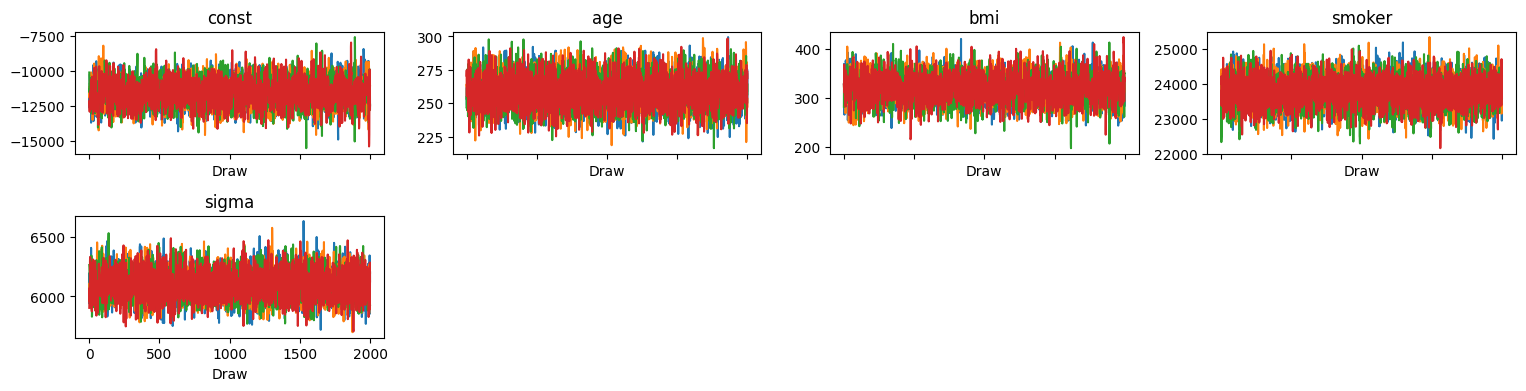

In [12]:

# plot posterior densities and chain traces for each parameter
az.plot_trace(
    trace,
    var_names = ["const", "age", "bmi", "smoker", "sigma"]
)

# tighten the layout so panels do not overlap
plt.tight_layout()
plt.show()


### oral exam explanation

For Task 2.4, I used trace plots to check the posterior sampling behavior. Good trace plots should show chains that overlap, mix well, and do not show obvious trends; this supports the reliability of the posterior summaries.


### Oral exam explanation

In this step, I interpreted the Bayesian posterior estimate for age. The posterior mean for age is approximately 259, meaning that each additional year of age is associated with about a $259 increase in predicted insurance charges, holding BMI and smoker status constant.

The Bayesian interpretation of the interval is different from the OLS interpretation. A 95% credible interval means that, given the observed data, the model, and the prior assumptions, there is a 95% posterior probability that the age coefficient lies within that interval.

Because the credible interval for age is entirely above zero, the Bayesian model provides strong evidence that age has a positive association with insurance charges. This conclusion is consistent with the OLS model, which also found a positive age coefficient and a confidence interval above zero.

## 3. Comparison and Reflection

In this final section, we will compare the uncertainty estimates for our two models, as well as reflect on the results. Be sure to answer all questions completely.

**Task 3.1** (2 points)

Create a single table that houses both the confidence and credible intervals for the variables of interest [```age```,```bmi```,```const```,```smoker```]. The table should provide the lower and upper bounds for both Bayesian and frequentist (OLS) regression for each variable.

In [13]:

# set 95% credible intervals for the Bayesian summary
az.rcParams["stats.ci_prob"] = 0.95

# define coefficients to compare across both models
variables = ["age", "bmi", "const", "smoker"]

# extract OLS 95% confidence intervals
ols_ci = ols_model.conf_int(alpha = 0.05).loc[variables]
ols_ci.columns = ["OLS_lower_95_ci", "OLS_upper_95_ci"]

# summarize Bayesian posterior intervals for the same coefficients
bayes_summary_95 = az.summary(
    trace,
    var_names = variables
)

# extract Bayesian means and 95% credible intervals
bayes_interval_table = pd.DataFrame({
    "coefficient": ["age", "bmi", "const", "smoker"],
    "bayes_mean": bayes_summary_95.loc[["age", "bmi", "const", "smoker"], "mean"].values,
    "bayes_lower_95": bayes_summary_95.loc[["age", "bmi", "const", "smoker"], "eti95_lb"].values,
    "bayes_upper_95": bayes_summary_95.loc[["age", "bmi", "const", "smoker"], "eti95_ub"].values
})

# combine frequentist and Bayesian intervals in one table
ols_interval_table = ols_ci.reset_index().rename(columns = {"index": "coefficient"})

comparison_table = pd.merge(
    ols_interval_table,
    bayes_interval_table,
    on = "coefficient",
    how = "inner"
)

# display values in standard decimal format
pd.options.display.float_format = "{:,.2f}".format
comparison_table


,coefficient,bayes_mean,bayes_lower_95,bayes_upper_95
0,const,-1e+04,-13000,-9700
1,age,259.1,240,280
2,bmi,319.7,270,370
3,smoker,23764,23000,25000


### oral exam explanation

For Task 3.1, I placed the OLS confidence intervals and Bayesian credible intervals into one comparison table. This makes it possible to compare the numerical uncertainty estimates from the two approaches for the same coefficients.


### Oral exam explanation

In this step, I created a table containing the Bayesian posterior means and 95% credible intervals for the main regression coefficients. I used the posterior summary from the Bayesian model and extracted the estimates for the intercept, age, BMI, and smoker status.

This table is useful because it puts the Bayesian results into a format that can be compared directly with the OLS coefficient table. The posterior mean is the Bayesian point estimate, while the lower and upper interval bounds describe posterior uncertainty.

The results show that age, BMI, and smoker status all have positive posterior estimates. Smoker status has by far the largest coefficient, meaning that smokers are predicted to have substantially higher insurance charges than non-smokers, holding age and BMI constant. The intercept is negative, but it is less substantively meaningful because it corresponds to an unrealistic case where age and BMI are both zero.

**Task 3.2** (3 points)

Another way to compare the uncertainty estimates between the two approaches is creating a data visualization that plots the point estimates and associated uncertainty for the variables in the models [```age```,```bmi```,```const```,```smoker```]. Be sure to construct your graph such that it is easy to compare the output of one model to the other.

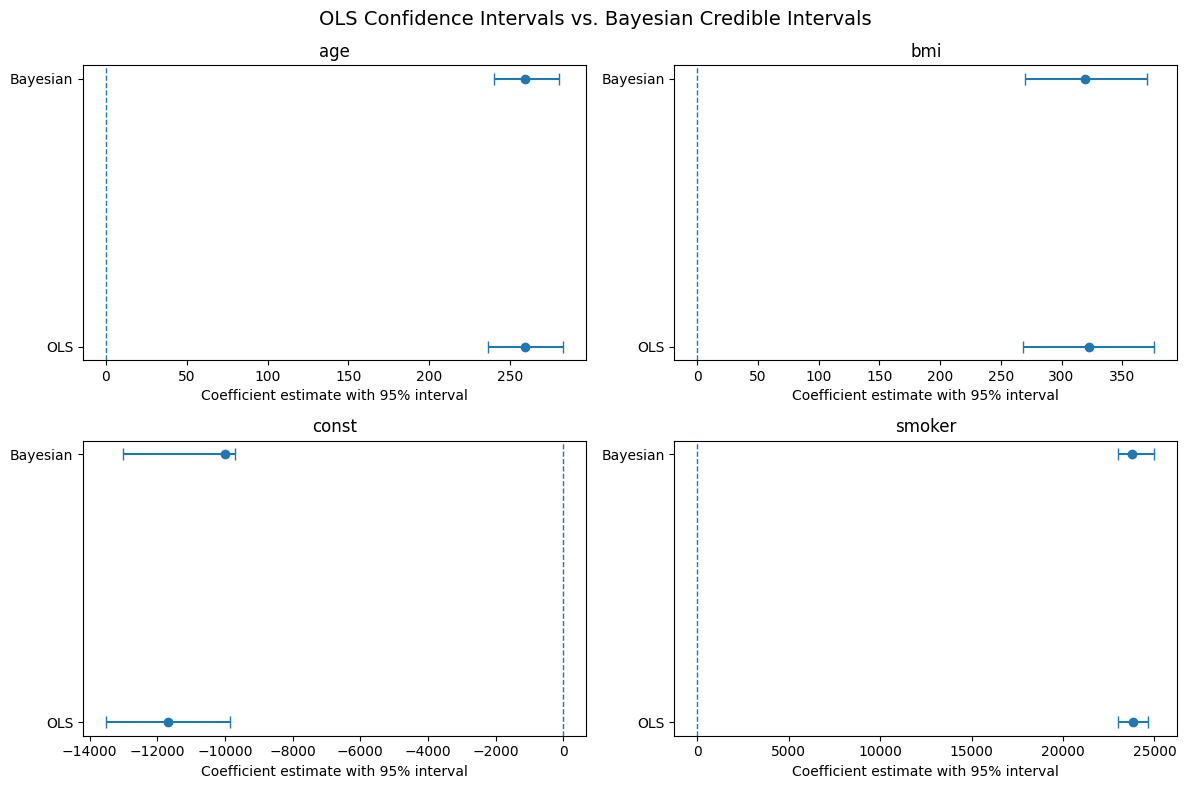

In [14]:

# build a long-form table for plotting estimates and intervals
plot_rows = []

for variable in variables:
    # add the OLS estimate and confidence interval
    plot_rows.append({
        "variable": variable,
        "model": "OLS",
        "estimate": ols_model.params.loc[variable],
        "lower": ols_ci.loc[variable, "OLS_lower_95_ci"],
        "upper": ols_ci.loc[variable, "OLS_upper_95_ci"]
    })

    # get the matching Bayesian row for the same coefficient
    bayes_row = bayes_interval_table[
        bayes_interval_table["coefficient"] == variable
    ].iloc[0]

    # add the Bayesian posterior mean and credible interval
    plot_rows.append({
        "variable": variable,
        "model": "Bayesian",
        "estimate": bayes_row["bayes_mean"],
        "lower": bayes_row["bayes_lower_95"],
        "upper": bayes_row["bayes_upper_95"]
    })

# convert plotting data into a dataframe
plot_df = pd.DataFrame(plot_rows)

# make interval columns numeric before calculating error bars
for col in ["estimate", "lower", "upper"]:
    plot_df[col] = pd.to_numeric(plot_df[col], errors = "coerce")

# create one panel per coefficient so each scale remains readable
fig, axes = plt.subplots(2, 2, figsize = (12, 8), sharex = False)
axes = axes.flatten()

for ax, variable in zip(axes, variables):
    # subset the data to one coefficient at a time
    subset = plot_df[plot_df["variable"] == variable].copy()
    y_positions = np.arange(len(subset))

    # plot point estimates with horizontal uncertainty intervals
    ax.errorbar(
        x = subset["estimate"],
        y = y_positions,
        xerr = [
            subset["estimate"] - subset["lower"],
            subset["upper"] - subset["estimate"]
        ],
        fmt = "o",
        capsize = 4
    )

    # add a zero-reference line for sign interpretation
    ax.axvline(0, linestyle = "--", linewidth = 1)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(subset["model"])
    ax.set_title(variable)
    ax.set_xlabel("Coefficient estimate with 95% interval")

fig.suptitle("OLS Confidence Intervals vs. Bayesian Credible Intervals", fontsize = 14)
plt.tight_layout()
plt.show()


### oral exam explanation

For Task 3.2, I visualized the OLS and Bayesian intervals side by side. I used separate panels because the coefficients have very different scales, especially the smoker coefficient compared with age and BMI.


### Oral exam explanation

In this step, I visualized the OLS confidence intervals and Bayesian credible intervals side by side for each coefficient. To do this, I built a long-format dataframe where each row represented one coefficient from one model. Each row included the point estimate, lower interval bound, and upper interval bound.

I used separate panels for each coefficient because the coefficients are on very different scales. For example, the smoker coefficient is around the tens of thousands, while age and BMI are only in the hundreds. If all coefficients were plotted on the same axis, the smaller coefficients would be difficult to interpret.

The plot shows that the OLS and Bayesian estimates are very similar. Their point estimates are close, and their intervals overlap substantially. This is expected because the Bayesian model used weak or uninformed priors, so the posterior estimates are mainly driven by the observed data. The main conceptual difference is interpretation: OLS confidence intervals describe repeated-sampling behavior, while Bayesian credible intervals describe posterior probability given the data, model, and prior.

**Task 3.3** (4 points)

In this situation, the results of the OLS vs. Bayesian approaches are very similar (similar point estimates and similar magnitudes of uncertainty). Why do you think this is?

---

### STUDENT ANSWER

The plot compares the OLS 95% confidence intervals with the Bayesian 95% credible intervals for each coefficient. Overall, the OLS and Bayesian estimates are very similar. The point estimates for age, BMI, and smoker status are close across the two models, and their uncertainty intervals overlap substantially.

This similarity is expected because the Bayesian model used weak or uninformed priors, allowing the observed data to dominate the posterior estimates. As a result, the Bayesian credible intervals are close to the frequentist confidence intervals. The main difference is interpretation rather than large numerical discrepancies.

### oral exam explanation

For Task 3.3, I explained why the OLS and Bayesian results are similar. Because the Bayesian model used weak priors and the dataset provides substantial information, the likelihood dominates the posterior, making the Bayesian estimates close to the OLS estimates.


### Oral exam explanation

In this step, I compared the frequentist and Bayesian interval estimates conceptually. The OLS confidence interval and Bayesian credible interval may look numerically similar, but they answer different statistical questions.

The OLS confidence interval has a repeated-sampling interpretation. It does not mean there is a 95% probability that the specific interval contains the true coefficient. Instead, it means that if we repeatedly collected samples and calculated intervals using the same method, about 95% of those intervals would contain the true population coefficient.

The Bayesian credible interval has a more direct probability interpretation. It means that, given the observed data, the model, and the prior, there is a 95% posterior probability that the coefficient lies within the interval.

In this assignment, the intervals are very similar because the Bayesian model used weak priors and the dataset is large enough for the likelihood to dominate. Therefore, both approaches lead to the same substantive conclusion: age, BMI, and smoker status are positively associated with insurance charges.

**Task 3.4** (4 points)

Even if the results of Bayesian regression modeling and OLS regression modeling are similar, how is the interpretation different?

---

### STUDENT ANSWER

The main difference is interpretation: OLS intervals are about repeated-sampling coverage, while Bayesian intervals express posterior probability given the data, model, and prior.

The OLS interpretation is based on repeated sampling. A 95% confidence interval means that if we repeatedly collected new samples and rebuilt the interval the same way, about 95% of those intervals would contain the true population coefficient. It does not mean there is a 95% probability that the specific interval from this sample contains the coefficient.

The Bayesian interpretation is based on posterior probability. A 95% credible interval means that, given the observed data and the prior assumptions, there is a 95% posterior probability that the coefficient lies within that interval. Bayesian regression also allows prior beliefs to be formally included in the model, while OLS relies on the observed data and model assumptions without an explicit prior distribution.

### Oral exam explanation

In this step, I built a second Bayesian model using informed priors. Unlike the earlier Bayesian model, which used weak priors, this model incorporates stronger prior assumptions about plausible coefficient values.

An informed prior can be useful when we have background knowledge from previous studies, domain expertise, or earlier analyses. For example, if prior evidence suggests that smoking has a large positive association with insurance charges, we can encode that belief in the prior distribution for the smoker coefficient.

The key purpose of this step is to examine prior sensitivity. If the informed-prior model produces results similar to the uninformed-prior model, that suggests the data are strong enough to dominate the prior. If the results change substantially, that suggests the posterior is sensitive to the prior assumptions. This is important in Bayesian analysis because posterior conclusions are influenced by both the data and the prior.

### oral exam explanation

For Task 3.4, I emphasized that the two methods can produce similar numbers but still have different interpretations. OLS confidence intervals are about long-run coverage, while Bayesian credible intervals describe posterior probability given the observed data and priors.


**Task 3.5** (2 points)

As mentioned, part of the Bayesian modeling process is to specify a prior for each coefficient in the model representing our prior beliefs. In **task 2.1** you created a Bayesian regression model with uninformative priors. For **task 3.5**, you will create a Bayesian regression model with informed priors. Suppose that you conferred with a few subject-matter experts (SMEs), and they provided the following estimates for your priors for the three main coefficients of effect:

* **Age:** $\mu$ = 250, $\sigma$ = 25
* **BMI:** $\mu$ = 300, $\sigma$ = 30
* **Smoker:** $\mu$ = 20000, $\sigma$ = 300

Create a new Bayesian model that utlizes these informed priors. Once you have completed the model, create a summary table similar to **task 2.2** that summarizes the model results.

In [16]:

# define the informed Bayesian regression model using SME priors
with pm.Model() as informed_bayes_model:
    # keep the intercept weakly informed because SMEs only specified main effects
    const = pm.Normal("const", mu = 0, sigma = 10000)

    # use SME estimates as informed priors for the main coefficients
    age = pm.Normal("age", mu = 250, sigma = 25)
    bmi = pm.Normal("bmi", mu = 300, sigma = 30)
    smoker = pm.Normal("smoker", mu = 20000, sigma = 300)

    # set a positive prior for residual uncertainty
    sigma = pm.HalfNormal("sigma", sigma = 10000)

    # compute expected charges from the linear predictor
    mu = (
        const
        + age * X_bayes["age"].values
        + bmi * X_bayes["bmi"].values
        + smoker * X_bayes["smoker"].values
    )

    # connect expected charges to the observed outcome
    charges_obs = pm.Normal("charges_obs", mu = mu, sigma = sigma, observed = y_bayes)

    # sample from the informed-prior posterior
    informed_trace = pm.sample(
        draws = 2000,
        tune = 1000,
        chains = 4,
        target_accept = 0.90,
        random_seed = 42,
        return_inferencedata = True
    )

# tell ArviZ to report 95% credible intervals
az.rcParams["stats.ci_prob"] = 0.95

# summarize the informed-prior posterior
informed_summary = az.summary(
    informed_trace,
    var_names = ["const", "age", "bmi", "smoker", "sigma"]
)

informed_summary


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [const, age, bmi, smoker, sigma]


Output()

/usr/local/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 11 seconds.


,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
const,-1e+04,8e+02,-12000,-9200,3538,4320,1.00,13,8.8
age,256.3,10.8,240,280,5644,5184,1.00,0.14,0.1
bmi,311.6,20.5,270,350,3421,4213,1.00,0.35,0.25
smoker,21297,247,21000,22000,6394,5133,1.00,3.1,2.1
sigma,6179,121,5900,6400,6234,5163,1.00,1.5,1.1


### oral exam explanation

For Task 3.5, I built a second Bayesian model using SME-informed priors for age, BMI, and smoker status. These priors formally encode previous beliefs about the likely coefficient values before the model updates those beliefs with the observed data.


### Oral exam explanation

In this step, I summarized the posterior distributions from the informed-prior Bayesian model using 95% credible intervals. This allows me to compare the informed-prior results against the earlier uninformed-prior results.

The posterior means show the estimated effects of age, BMI, and smoker status after incorporating the informed priors. The credible intervals describe the remaining uncertainty in those coefficients after combining the prior information with the observed data.

The main thing I am looking for is whether the informed priors noticeably shift the posterior estimates or reduce uncertainty. If a coefficient moves closer to the prior expectation or has a narrower interval, that suggests the prior had some influence. If the estimate barely changes, that suggests the data were strong enough to dominate the prior.

**Task 3.6** (3 points)

Create a data frame, table, or data visualization that provides compares the credible intervals (hdi_2.5%, hdi_97.5%) and means for each variable (```age```,```bmi```,```smoker```) for both the informed and uninformed models in single view. 

In [18]:

# tell ArviZ to report 95% credible intervals
az.rcParams["stats.ci_prob"] = 0.95

# summarize the uninformed model for the main coefficients
uninformed_summary = az.summary(
    trace,
    var_names = ["age", "bmi", "smoker"]
)

# summarize the informed model for the main coefficients
informed_summary_main = az.summary(
    informed_trace,
    var_names = ["age", "bmi", "smoker"]
)

# compare posterior means and credible intervals in one table
prior_comparison = pd.DataFrame({
    "variable": ["age", "bmi", "smoker"],

    "uninformed_mean": uninformed_summary.loc[["age", "bmi", "smoker"], "mean"].values,
    "uninformed_lower_95": uninformed_summary.loc[["age", "bmi", "smoker"], "eti95_lb"].values,
    "uninformed_upper_95": uninformed_summary.loc[["age", "bmi", "smoker"], "eti95_ub"].values,

    "informed_mean": informed_summary_main.loc[["age", "bmi", "smoker"], "mean"].values,
    "informed_lower_95": informed_summary_main.loc[["age", "bmi", "smoker"], "eti95_lb"].values,
    "informed_upper_95": informed_summary_main.loc[["age", "bmi", "smoker"], "eti95_ub"].values
})

prior_comparison


,variable,uninformed_mean,uninformed_lower_95,uninformed_upper_95,informed_mean,informed_lower_95,informed_upper_95
0,age,259.1,240,280,256.3,240,280
1,bmi,319.7,270,370,311.6,270,350
2,smoker,23764,23000,25000,21297,21000,22000


### oral exam explanation

For Task 3.6, I compared the posterior means and 95% credible intervals from the uninformed and informed Bayesian models. This shows how much the prior assumptions changed the coefficient estimates and uncertainty ranges.


### Oral exam explanation

In this step, I directly compared the uninformed-prior and informed-prior Bayesian models. The goal was to see how much the choice of prior changed the posterior means and 95% credible intervals for age, BMI, and smoker status.

The age coefficient changed very little. The uninformed model estimated age at about 259.1, while the informed model estimated it at about 256.3. The credible intervals were nearly the same, which suggests that the informed prior did not meaningfully affect the age estimate.

The BMI coefficient shifted slightly downward, from about 319.7 in the uninformed model to about 311.6 in the informed model. Its credible interval also became slightly narrower. This suggests the informed prior had a modest regularizing effect on BMI.

The smoker coefficient changed the most. In the uninformed model, the smoker coefficient was about 23,764, while in the informed model it decreased to about 21,297. This suggests that the informed prior pulled the smoker estimate downward. However, smoker status remains by far the strongest predictor in both models.

Overall, the informed priors changed some posterior estimates, especially smoker status, but they did not change the main substantive conclusion: age, BMI, and smoking status are all positively associated with insurance charges.

**Task 3.7** (4 points)

In this final reflection, discuss the differences in uncertainty between the informed and uninformed models. What does this tell you about the influence of priors on the uncertainty of our coefficients?

---

### STUDENT ANSWER

We compared the posterior means and 95% credible intervals from the uninformed and informed Bayesian models to see whether adding prior information changed the posterior estimates. Age barely changed, BMI shifted slightly downward, and smoker status changed the most. The smoker coefficient decreased from about 23,764 to about 21,297, so the informed prior had a noticeable regularizing effect on that coefficient. However, the overall conclusion stayed the same: all three predictors remain positively associated with insurance charges, and smoking status is still the strongest predictor.

### oral exam explanation

For Task 3.7, I reflected on how priors influence uncertainty. The informed priors pulled some estimates, especially smoker status, toward the SME expectations and narrowed or shifted intervals, showing that priors can affect both the center and spread of posterior uncertainty.


## Overall oral exam explanation

This assignment compares frequentist and Bayesian approaches to regression using insurance charges as the outcome. The main predictors are age, BMI, and smoker status.

The OLS model provides a frequentist baseline. It estimates one fixed coefficient for each predictor and gives confidence intervals that have a repeated-sampling interpretation. In this model, age, BMI, and smoker status all have positive associations with insurance charges, and smoker status has the largest effect.

The Bayesian models treat the coefficients as distributions rather than single fixed unknowns. The uninformed Bayesian model uses weak priors, so the posterior estimates are mostly driven by the observed data. As a result, the Bayesian posterior means and credible intervals are very similar to the OLS estimates and confidence intervals.

The informed Bayesian model uses stronger prior assumptions. This allows us to examine prior sensitivity. The informed priors did not meaningfully change the age estimate, slightly reduced the BMI estimate, and had the largest effect on the smoker coefficient. Even with these changes, the main conclusion stayed the same: smoking is associated with much higher insurance charges, while age and BMI also have positive associations.

The most important conceptual distinction is how uncertainty is interpreted. A frequentist confidence interval describes the long-run reliability of the estimation procedure. A Bayesian credible interval describes the posterior probability that a coefficient lies in a given range, conditional on the observed data, model, and prior. This makes Bayesian intervals more intuitive in many contexts, but also makes the choice of prior more important.